In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, Dropout

In [21]:
dataset = pd.read_csv('goog.csv')
dataset.head()

,Date,Open,High,Low,Close,Volume
0,12/19/2016,790.219971,797.659973,786.270020,794.200012,1225900
1,12/20/2016,796.760010,798.650024,793.270020,796.419983,925100
2,12/21/2016,795.840027,796.676025,787.099976,794.559998,1208700
3,12/22/2016,792.359985,793.320007,788.580017,791.260010,969100
4,12/23/2016,790.900024,792.739990,787.280029,789.909973,623400


In [22]:
# Only choosing open column
training_set = dataset[["Open"]].values

In [23]:
# scaled data
sc = MinMaxScaler(feature_range=(0,1))
training_set_scaled = scaler.fit_transform(training_set)
print(training_set_scaled)

[[0.15673043]
 [0.24656614]
 [0.23392901]
 [0.18612623]
 [0.16607182]
 [0.16304941]
 [0.2045332 ]
 [0.06208818]
 [0.05412092]
 [0.        ]
 [0.13118116]
 [0.09986292]
 [0.22596174]
 [0.37898394]
 [0.39903835]
 [0.35975284]
 [0.38914865]
 [0.3938185 ]
 [0.38832451]
 [0.37087919]
 [0.36140112]
 [0.38598874]
 [0.39065944]
 [0.59739008]
 [0.69793964]
 [0.81043971]
 [0.76785761]
 [0.4924448 ]
 [0.24793943]
 [0.28667581]
 [0.20590649]
 [0.33214281]
 [0.28695079]
 [0.34587907]
 [0.38722537]
 [0.42170354]
 [0.45178599]
 [0.51085177]
 [0.55206057]
 [0.55700542]
 [0.5648352 ]
 [0.60728063]
 [0.68475253]
 [0.68475253]
 [0.70480778]
 [0.67197789]
 [0.62829668]
 [0.64285708]
 [0.68736246]
 [0.75604379]
 [0.71085178]
 [0.66126405]
 [0.66744553]
 [0.75137393]
 [0.78557709]
 [0.88557751]
 [0.89546722]
 [0.89052237]
 [0.94478079]
 [0.96456104]
 [1.        ]]


In [24]:
# predicting the value from previous 10 records
x_train = []
y_train = []

for i in range(10, len(training_set_scaled)):
    x_train.append(training_set_scaled[i-10:i,0])
    y_train.append(training_set_scaled[i,0])

x_train = np.array(x_train)
y_train = np.array(y_train)

In [6]:
# LSTM and RNN required 3D inputs
# Format -> (samples, time_steps, features)
x_train = np.reshape(x_train,(x_train.shape[0],x_train.shape[1],1))
print(x_train.shape)

(51, 10, 1)


In [7]:
rnn_model = Sequential()

rnn_model.add(SimpleRNN(units=50,return_sequences=True,input_shape=(x_train.shape[1],1)))
rnn_model.add(Dropout(0.2))

rnn_model.add(SimpleRNN(units=50))
rnn_model.add(Dropout(0.2))

rnn_model.add(Dense(units=1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:
rnn_model.compile(optimizer='adam',loss='mean_squared_error')

In [9]:
rnn_model.fit(x_train,y_train,epochs=100,batch_size=16)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.4505
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1671
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1294
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1025
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0706
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0824
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0906
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0585
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0742
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0588
Epoch 11/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0660
Epoch 12/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0401
Epoch 13/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0543
Epoch 14/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0313
Epoch 15/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0503
Epoch 16/100
4/4 ━━

In [10]:
rnn_predicted = rnn_model.predict(x_train)

rnn_predicted = scaler.inverse_transform(rnn_predicted)

real_prices = scaler.inverse_transform(y_train.reshape(-1,1))

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 583ms/step


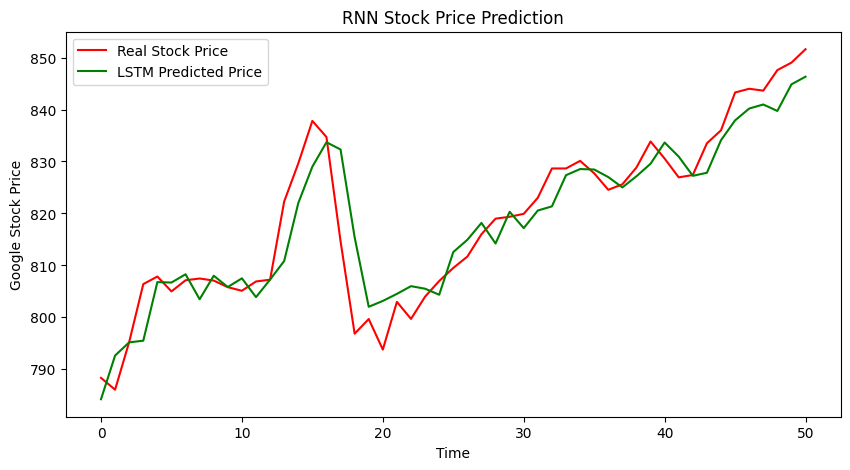

In [16]:
plt.figure(figsize=(10,5))

plt.plot(real_prices,color='red',label='Real Stock Price')
plt.plot(rnn_predicted,color='green',label='LSTM Predicted Price')

plt.title('RNN Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Google Stock Price')
plt.legend()
plt.show()

In [11]:
lstm_model = Sequential()

lstm_model.add(LSTM(units=50,return_sequences=True,input_shape=(x_train.shape[1],1)))
lstm_model.add(Dropout(0.2))

lstm_model.add(LSTM(units=50))
lstm_model.add(Dropout(0.2))

lstm_model.add(Dense(units=1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [12]:
lstm_model.compile(optimizer='adam',loss='mean_squared_error')

In [13]:
lstm_model.fit(x_train,y_train,epochs=100,batch_size=16)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.2967
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1400
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0466
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0382
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0347
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0306
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0317
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0277
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0303
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0262
Epoch 11/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0295
Epoch 12/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0274
Epoch 13/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0291
Epoch 14/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0263
Epoch 15/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0296
Epoch 16/100
4/4 ━━

In [14]:
lstm_predicted = lstm_model.predict(x_train)

lstm_predicted = scaler.inverse_transform(lstm_predicted)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 697ms/step


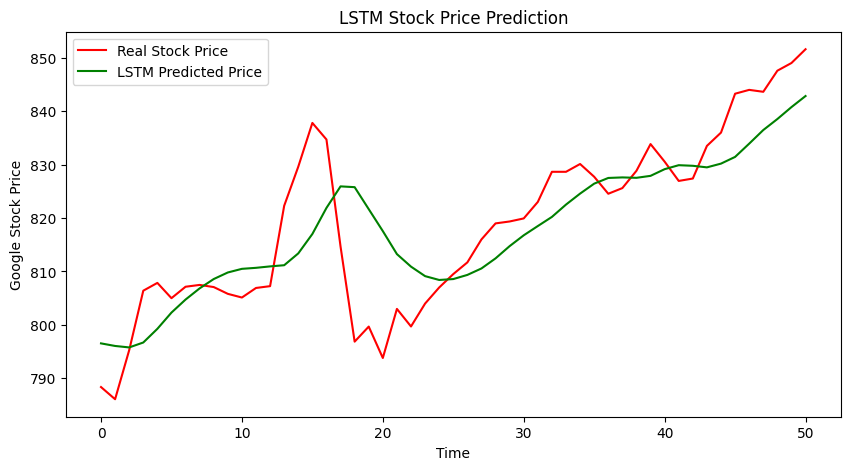

In [15]:
plt.figure(figsize=(10,5))

plt.plot(real_prices,color='red',label='Real Stock Price')
plt.plot(lstm_predicted,color='green',label='LSTM Predicted Price')

plt.title('LSTM Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Google Stock Price')
plt.legend()
plt.show()

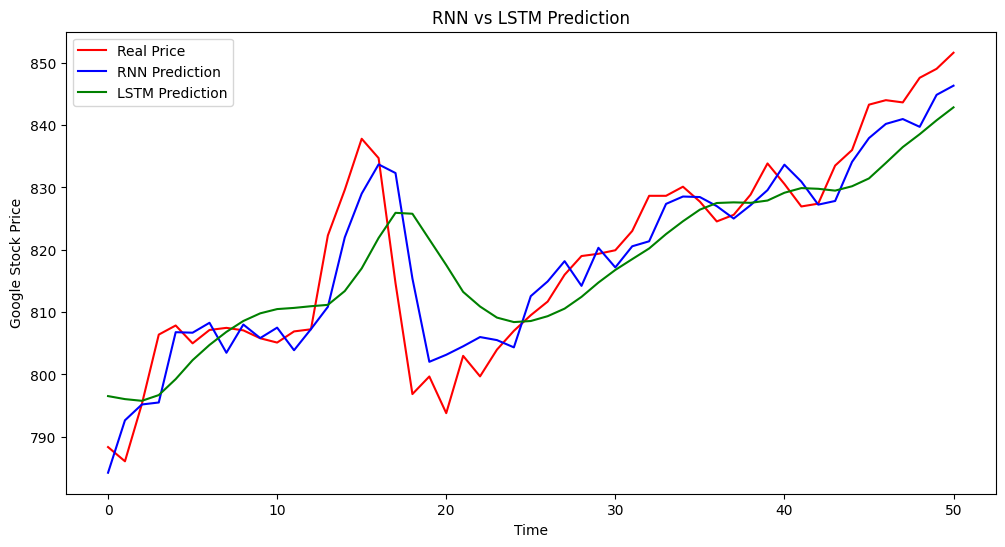

In [17]:
plt.figure(figsize=(12,6))

plt.plot(real_prices,color='red',label='Real Price')
plt.plot(rnn_predicted,color='blue',label='RNN Prediction')
plt.plot(lstm_predicted,color='green',label='LSTM Prediction')

plt.title('RNN vs LSTM Prediction')
plt.xlabel('Time')
plt.ylabel('Google Stock Price')
plt.legend()
plt.show()